# SARIMAX 07 — Diagnostics

Analyze previously saved validation predictions. No SARIMAX model is refitted in this notebook.

In [2]:
# Import libraries
from pathlib import Path
import sys
import json
import pandas as pd

import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

In [5]:
# Define project paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORTS_DIR = PROJECT_ROOT / "reports" / "modeling" / "forecasting" / "sarimax_rolling"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "modeling" / "forecasting" / "sarimax_rolling"

REPORTS_DIR, OUTPUTS_DIR

(WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/reports/modeling/forecasting/sarimax_rolling'),
 WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/outputs/modeling/forecasting/sarimax_rolling'))

In [6]:
# Get predictions
predictions = pd.read_parquet(OUTPUTS_DIR / "sarimax_rolling_validation_predictions.parquet")
predictions["forecast_origin"] = pd.to_datetime(predictions["forecast_origin"])
predictions["residual"] = predictions["actual"] - predictions["predicted"]


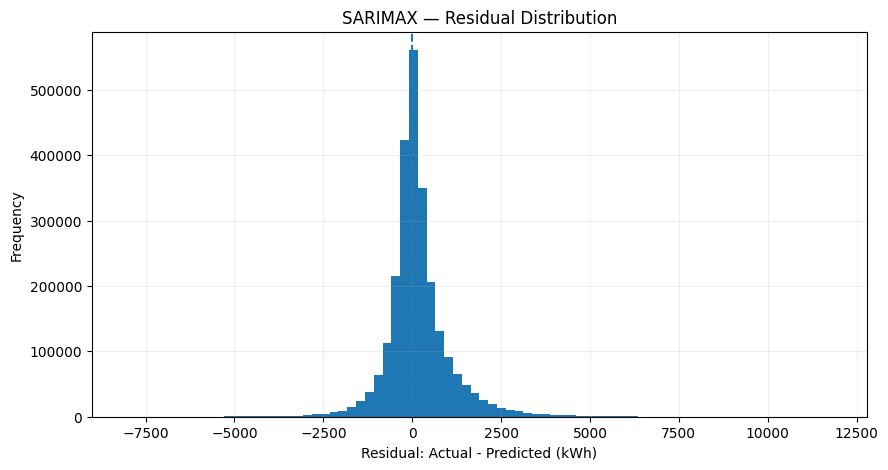

In [7]:
# SARIMAX — Residual Distribution
plt.figure(figsize=(10, 5))
plt.hist(predictions["residual"].dropna(), bins=80)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual: Actual - Predicted (kWh)")
plt.ylabel("Frequency")
plt.title("SARIMAX — Residual Distribution")
plt.grid(alpha=0.2)
plt.show()


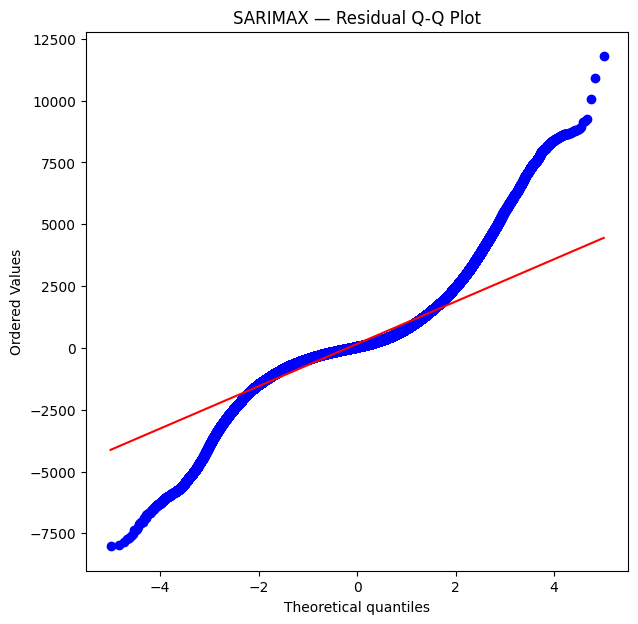

In [8]:
# SARIMAX — Residual Q-Q Plot
plt.figure(figsize=(7, 7))
stats.probplot(predictions["residual"].dropna(), dist="norm", plot=plt)
plt.title("SARIMAX — Residual Q-Q Plot")
plt.show()


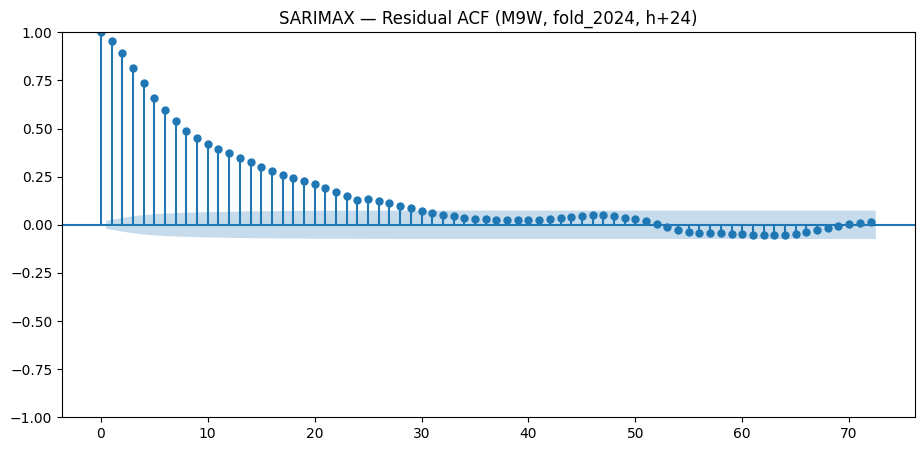

In [9]:
# SARIMAX — Residual ACF
acf_series = (
    predictions
    .query("fold == 'fold_2024' and fsa == 'M9W' and horizon == 24")
    .sort_values("forecast_origin")["residual"]
    .dropna()
)
plt.figure(figsize=(11, 5))
plot_acf(acf_series, lags=72, ax=plt.gca())
plt.title("SARIMAX — Residual ACF (M9W, fold_2024, h+24)")
plt.show()


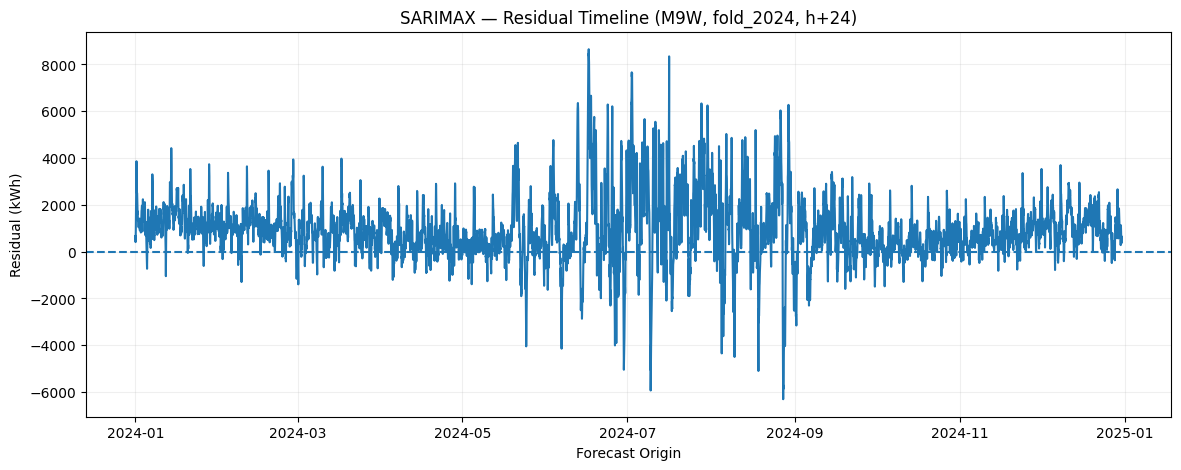

In [10]:
# SARIMAX — Residual Timeline
timeline = (
    predictions
    .query("fold == 'fold_2024' and fsa == 'M9W' and horizon == 24")
    .sort_values("forecast_origin")
)
plt.figure(figsize=(14, 5))
plt.plot(timeline["forecast_origin"], timeline["residual"])
plt.axhline(0, linestyle="--")
plt.xlabel("Forecast Origin")
plt.ylabel("Residual (kWh)")
plt.title("SARIMAX — Residual Timeline (M9W, fold_2024, h+24)")
plt.grid(alpha=0.2)
plt.show()


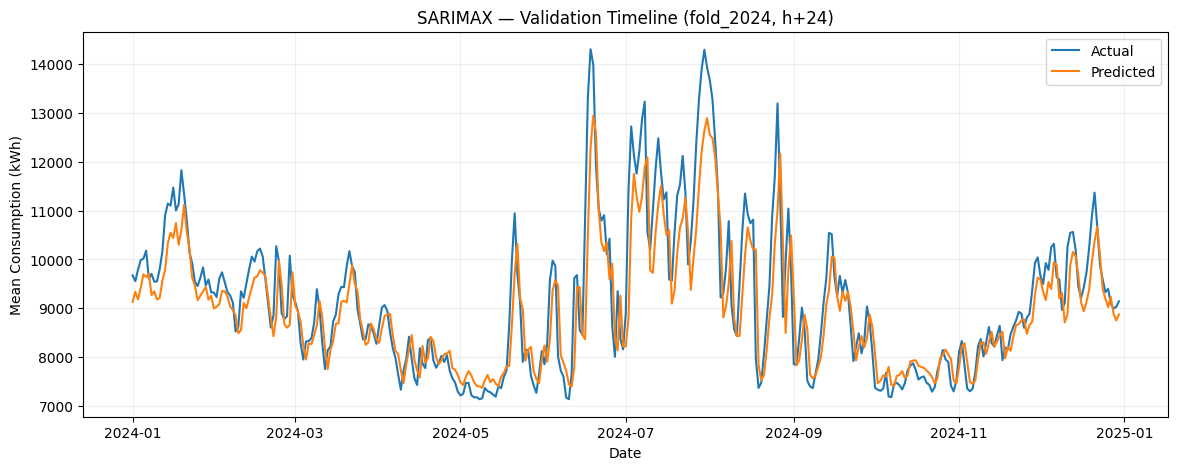

In [11]:
# SARIMAX — Validation Timeline
timeline = predictions.query("fold == 'fold_2024' and horizon == 24").copy()
timeline["date"] = timeline["forecast_origin"].dt.floor("D")
daily = (
    timeline.groupby("date", observed=True)
    .agg(actual=("actual", "mean"), predicted=("predicted", "mean"))
    .reset_index()
)
plt.figure(figsize=(14, 5))
plt.plot(daily["date"], daily["actual"], label="Actual")
plt.plot(daily["date"], daily["predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("Mean Consumption (kWh)")
plt.title("SARIMAX — Validation Timeline (fold_2024, h+24)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()
